# Still-life tile search for any Life-like rule

This notebook is the *parametrized* companion to `tile_generation_sat.ipynb`. Where that notebook tells the story of how the level-6 Conway database was cracked, this one is a reproducibility artifact: pick a **level** and a **B/S rule** in the configuration cell below, and every subsequent step — geometry, dead-edge derivation, symmetry-orbit reduction, SAT encoding, exhaustive enumeration, independent validation, and a gallery of the results — runs live for that choice.

The machinery lives in `gol_mosaics.tile_domain` (geometry and orbits), `gol_mosaics.sat_search` (CNF construction and enumeration) and `gol_mosaics.life` (an independent Life-like stepper used only for checking). For production-scale levels ($\geq 7$) use the parallel, checkpointed pipeline in `workstation/level6_search/` instead.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Import gol_mosaics (installed with: pip install -e .); fall back to ../src
# so the notebook also runs from a plain checkout.
try:
    import gol_mosaics
except ImportError:
    sys.path.insert(0, str(Path.cwd().parent / "src"))

from gol_mosaics import MosaicGenerator, PatternLibrary
from gol_mosaics.life import is_still_life, life_step
from gol_mosaics import tile_domain, sat_search

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "figure.dpi": 100,
    "savefig.dpi": 1200,
})

## Step 1: Configuration

A Life-like rule is written B$b_1b_2\ldots$/S$s_1s_2\ldots$: a dead cell becomes alive when its live-neighbour count is in the birth set, a live cell stays alive when its count is in the survival set. Conway's Game of Life is B3/S23. Set `LEVEL`, `BIRTH` and `SURVIVAL` here — either from a preset or by hand — and run the rest of the notebook unchanged.

Guidance on the level: levels $\leq 5$ enumerate in well under a second, level 6 takes tens of seconds single-threaded (332,321 tiles for Conway), and level $\geq 7$ automatically switches to a *bounded probe* of the first few thousand tiles — the complete run belongs on the parallel pipeline.

In [2]:
PRESETS = {
    "conway":     ((3,), (2, 3)),    # B3/S23
    "highlife":   ((3, 6), (2, 3)),  # B36/S23
    "pedestrian": ((3, 8), (2, 3)),  # B38/S23
}

LEVEL = 4
BIRTH, SURVIVAL = PRESETS["conway"]

RULE = f"B{''.join(map(str, BIRTH))}/S{''.join(map(str, SURVIVAL))}"
n = 6 * LEVEL
print(f"Searching level {LEVEL} ({n}x{n} tiles) under {RULE}")

Searching level 4 (24x24 tiles) under B3/S23


**Precondition.** The whole construction rests on the *pond* — the $4\times4$ still life whose copies form the tile borders. A rule can only host these mosaics if the pond is a still life under it, so we check that first and fail fast otherwise. (For example, Day \& Night, B3678/S34678, fails here: each live pond cell has only 2 live neighbours and $2 \notin S$.)

In [3]:
pond = np.pad(tile_domain.pond_pattern(), 2)
assert is_still_life(pond, BIRTH, SURVIVAL), (
    f"the pond is not a still life under {RULE}; "
    "the mosaic construction does not apply to this rule")
print(f"pond is a still life under {RULE} \N{CHECK MARK}")

pond is a still life under B3/S23 ✓


## Step 2: Geometry and the derived dead edges

A tile of level $L$ is an $n \times n$ grid, $n = 6L$, with three geometric constraint families before the CA rule even enters: the pond ring along the tile's diamond edge is forced **alive**, everything outside the diamond is forced **dead**, and a small set of near-edge cells — the **dead edges** — is forced dead so that *any* two tiles placed side by side in a mosaic cannot interact.

The dead edges are not hand-made: `tile_domain.derive_dead_edges` computes them from the mosaic geometry alone (which cells of a tile share a neighbourhood with a neighbouring tile's free cells), reproducing the historical hand-crafted lists for levels 2–6 exactly and yielding $12L - 8$ cells at every level $\geq 2$. This derivation is rule-independent — it only uses the range-1 Moore neighbourhood that all Life-like rules share.

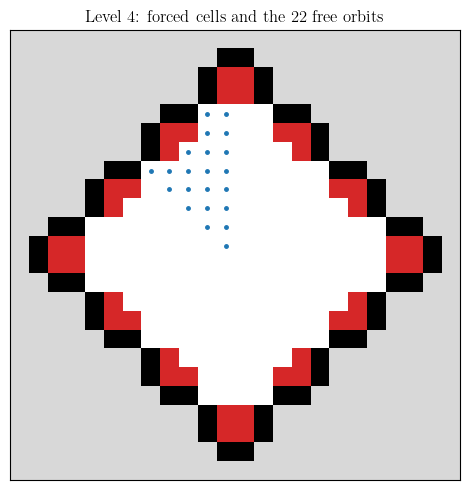

derived dead edges: 40 cells (= 12L-8) ✓, octant representatives: [(2, 12), (3, 12), (5, 14), (5, 15), (6, 15)]


In [4]:
d = tile_domain.build_domain(LEVEL)
edge_alive, outside_dead, dead_edges = tile_domain.forced_masks(LEVEL)

classes = np.zeros((n, n))              # free
classes[outside_dead == 1] = 1          # outside the diamond
classes[edge_alive == 1] = 2            # forced-alive pond edge
full_dead = sorted(tile_domain.derive_dead_edges_full(LEVEL))
for (i, j) in full_dead:
    classes[i, j] = 3                   # forced-dead interlock cells

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(classes, cmap=plt.matplotlib.colors.ListedColormap(
    ["white", "0.85", "black", "tab:red"]), interpolation="nearest")
ax.set_title(f"Level {LEVEL}: forced cells and the {len(d.free_reps)} free orbits")
ax.set_xticks([]); ax.set_yticks([])
for (i, j) in d.free_reps:
    ax.plot(j, i, ".", color="tab:blue", markersize=5)
plt.tight_layout()
plt.show()

expected = 12 * LEVEL - 8 if LEVEL >= 2 else 0
assert len(full_dead) == expected
print(f"derived dead edges: {len(full_dead)} cells (= 12L-8) \N{CHECK MARK}, "
      f"octant representatives: {tile_domain.derive_dead_edges(LEVEL)}")

## Step 3: Symmetry-orbit reduction

Tiles are invariant under the full dihedral group $D_4$, so a tile is determined by one value per **orbit** (up to 8 cells mapped onto each other by the symmetries), and whenever any cell of an orbit is forced, the whole orbit is. What remains free is small:

In [5]:
print(f"{'level':>5} {'grid':>8} {'cells':>6} {'free orbits':>12}")
for L in range(1, 8):
    dl = tile_domain.build_domain(L)
    print(f"{L:>5} {f'{dl.n}x{dl.n}':>8} {dl.n**2:>6} {len(dl.free_reps):>12}")

level     grid  cells  free orbits
    1      6x6     36            1
    2    12x12    144            3
    3    18x18    324           10
    4    24x24    576           22
    5    30x30    900           38
    6    36x36   1296           59
    7    42x42   1764           84


## Step 4: The SAT encoding

One boolean variable per free orbit. For every cell of the grid, its 8 neighbour *positions* resolve to orbit variables or constants, and each illegal exact neighbour count $c$ is forbidden with binomial clauses — for a live cell every $c \notin S$, for a dead cell every $c \in B$. Two properties carry the exactness argument: positions form a *multiset* (near a symmetry axis several positions share a variable, and the clause simplifier reproduces positional counting), and there are **no auxiliary variables**, so a blocking clause over the decision variables removes exactly one assignment during enumeration. The formula carries a SHA-256 fingerprint that covers the level, the rule and every clause.

In [6]:
t0 = time.time()
enc = sat_search.build_cnf(LEVEL, BIRTH, SURVIVAL)
print(f"level {LEVEL}, {RULE}: {enc.n_vars} variables, {len(enc.clauses)} clauses, "
      f"built in {time.time() - t0:.2f}s\nfingerprint {enc.sha256}")

level 4, B3/S23: 22 variables, 1340 clauses, built in 0.08s
fingerprint 83120d119db93fbdaeb62f982ae6e6ceaf905ce18849776444a375b5abd3b665


## Step 5: Exhaustive enumeration

The AllSAT loop — solve, record, block, repeat until UNSAT — visits every solution exactly once. For level $\geq 7$ we bound the probe; everything below that runs to provable completion (the final solver call returns UNSAT, certifying that no further tile exists).

In [7]:
LIMIT = 5_000 if LEVEL >= 7 else None
if LIMIT:
    print(f"level {LEVEL} >= 7: bounded probe of the first {LIMIT} tiles "
          "(complete runs: workstation/level6_search/)")

t0 = time.time()
bits = sat_search.enumerate_all(enc, limit=LIMIT)
elapsed = time.time() - t0
tiles = enc.domain.expand_many(bits)
order = sorted(range(len(tiles)),
               key=lambda i: (int(tiles[i].sum()), tiles[i].tobytes()))
tiles = tiles[order]

complete = LIMIT is None or len(tiles) < LIMIT
status = "complete (final call returned UNSAT)" if complete else "bounded probe"
print(f"{len(tiles)} tiles of level {LEVEL} under {RULE} "
      f"in {elapsed:.2f}s — {status} \N{CHECK MARK}")

85 tiles of level 4 under B3/S23 in 0.01s — complete (final call returned UNSAT) ✓


## Step 6: Independent validation

Three checks, none of which shares code with the encoding:

1. **Per-tile verifier** — vectorised neighbour counting over the full grids confirms every tile satisfies the rule, the $D_4$ symmetry and all forcings.
2. **Isolation** — a padded tile must be a still life under the rule in open space.
3. **Whole-mosaic stability** — we assemble real mosaics from randomly mixed tiles with the production `MosaicGenerator` and require each to be a *global* still life under the rule. This is the check that exercises the dead edges: tiles enumerated without them pass checks 1–2 but fail here (see the narrative notebook's "teeth" demonstration).

In [8]:
violations = sat_search.rule_violations(tiles, BIRTH, SURVIVAL)
assert not violations.any()
print(f"1. independent verifier: {len(tiles)}/{len(tiles)} tiles valid \N{CHECK MARK}")

sample = tiles[:: max(1, len(tiles) // 50)]
for tile in sample:
    assert is_still_life(np.pad(tile, n), BIRTH, SURVIVAL)
print(f"2. isolation: {len(sample)} sampled tiles are still lifes "
      f"in open space \N{CHECK MARK}")

library = PatternLibrary(level=LEVEL)
library._solutions = tiles
generator = MosaicGenerator(level=LEVEL, grid_size=10)
generator._pattern_library = library

rng = np.random.default_rng(0)
mosaics = []
for seed in range(3):
    mosaic = generator._build_mosaic(
        rng.integers(0, 256, (6, 5)).astype(float),
        rng.integers(0, 256, (5, 6)).astype(float),
        empty_tiles_cutoff=1.0)
    mosaic = np.clip(mosaic, 0, 1)
    assert mosaic.sum() > 1000, "mosaic unexpectedly (near-)empty"
    assert is_still_life(mosaic, BIRTH, SURVIVAL), f"mosaic {seed} unstable!"
    mosaics.append(mosaic)
print(f"3. whole-mosaic stability: 3/3 random {mosaics[0].shape[0]}x"
      f"{mosaics[0].shape[1]} mosaics are global still lifes "
      f"under {RULE} \N{CHECK MARK}")

1. independent verifier: 85/85 tiles valid ✓
2. isolation: 85 sampled tiles are still lifes in open space ✓
3. whole-mosaic stability: 3/3 random 144x144 mosaics are global still lifes under B3/S23 ✓


## Step 7: The results

The census, a density histogram, the sparsest/median/densest tiles, one of the validated mosaics, and the packed storage round trip (free-orbit bits + `np.packbits`, the format in which large levels ship).

level 4, B3/S23: 85 tiles, live-cell counts 56..132 (median 96)


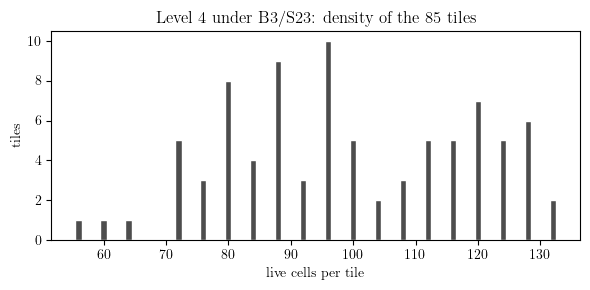

In [9]:
alive = tiles.reshape(len(tiles), -1).sum(axis=1)
print(f"level {LEVEL}, {RULE}: {len(tiles)} tiles, "
      f"live-cell counts {alive.min()}..{alive.max()} (median {int(np.median(alive))})")

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(alive, bins=np.arange(alive.min() - 0.5, alive.max() + 1.5),
        color="0.3", edgecolor="white")
ax.set_xlabel("live cells per tile")
ax.set_ylabel("tiles")
ax.set_title(f"Level {LEVEL} under {RULE}: density of the "
             f"{len(tiles)} tiles")
plt.tight_layout()
plt.show()

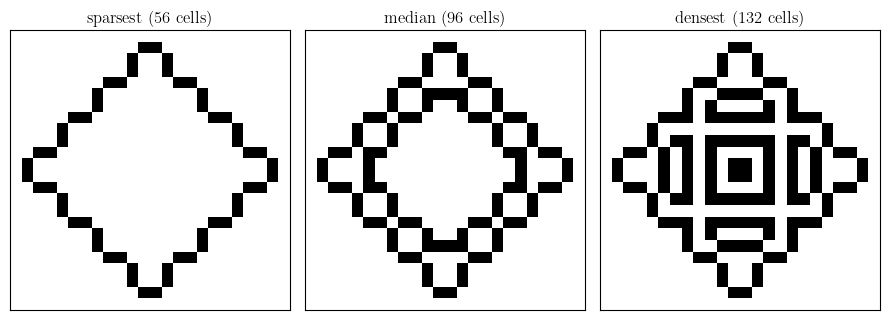

In [10]:
picks = [0, len(tiles) // 2, len(tiles) - 1]
labels = ["sparsest", "median", "densest"]
fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
for ax, k, lab in zip(axes, picks, labels):
    ax.imshow(tiles[k], cmap="binary", interpolation="nearest")
    ax.set_title(f"{lab} ({int(alive[k])} cells)")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

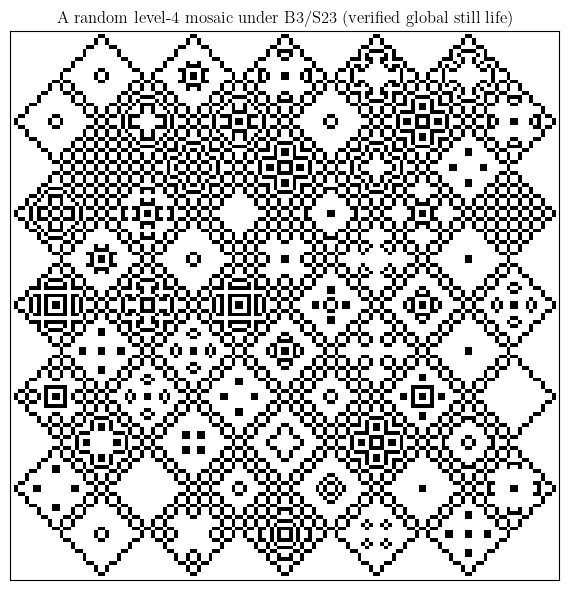

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(mosaics[0], cmap="binary", interpolation="nearest")
ax.set_title(f"A random level-{LEVEL} mosaic under {RULE} "
             "(verified global still life)")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

In [12]:
packed = tile_domain.pack_solutions(tiles, LEVEL)
restored = tile_domain.unpack_solutions(packed, LEVEL)
assert np.array_equal(restored, tiles)
print(f"packed storage: {tiles.nbytes:,} bytes -> {packed.nbytes:,} bytes "
      f"({tiles.nbytes / packed.nbytes:.0f}x), round trip byte-identical "
      f"\N{CHECK MARK}")

packed storage: 48,960 bytes -> 255 bytes (192x), round trip byte-identical ✓


## Step 8: Sweeping rules and levels

Finally, the same machinery across several rules and levels in one go — each cell of the table is an independent, provably exhaustive enumeration. Rules whose birth set strictly contains B3 (with survival S23) constrain dead cells *more* than Conway does, so their tile sets are subsets of Conway's.

In [13]:
sweep_levels = (3, 4, 5)
print(f"{'rule':>10} " + " ".join(f"{f'level {L}':>10}" for L in sweep_levels))
for name, (b, s) in PRESETS.items():
    counts = []
    for L in sweep_levels:
        found = sat_search.enumerate_tiles(L, b, s)
        assert not sat_search.rule_violations(found, b, s).any()
        counts.append(len(found))
    rule = f"B{''.join(map(str, b))}/S{''.join(map(str, s))}"
    print(f"{rule:>10} " + " ".join(f"{c:>10}" for c in counts))

      rule    level 3    level 4    level 5


    B3/S23          7         85       2632


   B36/S23          6         65       1519


   B38/S23          7         85       2632


Every count above is exact and verified. For Conway these match the shipped databases (7, 85, 2632); the HighLife column equals the independent post-filter of Conway's tiles (a dead cell with exactly 6 live neighbours is forbidden by B36), which the narrative notebook checks explicitly.

**Where to go next**

- `tile_generation_sat.ipynb` — the full level-6 story: why the ILP saturated, the five-tier validation ladder, level-6 galleries, and the level-7 outlook.
- `workstation/level6_search/` — the parallel, checkpointed production pipeline (`python search.py run --level 7 --cube-bits 16`) with packed output for $\sim 10^8$ tiles.
- `paper/` — the manuscript draft built on these results.